# 070 — Build final-event waveform products

Build fixed waveform segments and pulse-morphology measurements for the
authoritative 153-event catalogue established by Notebook 030. This notebook
does **not** reconstruct or redefine the event catalogue.

Pressure traces use the canonical 1.0 s moving-median baseline-corrected Stream
written by Notebook 010; seismic traces are unchanged by that preprocessing.


## Processing history

The workflow began with manual candidate-airwave picking in Antelope's `dbpick` program.
The original picks were recovered from MATLAB/GISMO with millisecond precision.
Legacy 153- and 157-event catalogues were compared, differential-delay
correction was introduced, filtering and local-linear baseline experiments were
tested, and a centered 1.0 s moving median was adopted for unfiltered pressure
measurements. The assumed 351 m/s speed is only an initial alignment model.
The simple compression–rarefaction measurement is a morphology diagnostic, not an event-existence test. A tightly associated multi-channel candidate is retained even when a complex waveform—most notably the principal explosion—does not contain a qualifying positive-then-negative pair.


## 1. Imports and paths

In [1]:
from pathlib import Path
from collections.abc import Mapping
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import Stream, Trace, UTCDateTime, read

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
FINAL_CATALOGUE_FILE = config.NB030_DIR / "final_153_event_catalogue.csv"
PICK_ASSIGNMENT_FILE = config.NB030_DIR / "reduced_time_pick_assignments.csv"

OUTPUT_DIR = config.NB070_DIR
EVENT_STREAM_DIR = OUTPUT_DIR / "event_streams"
FIGURE_DIR = OUTPUT_DIR / "figures"
DERIVED_OUTPUT_DIR = OUTPUT_DIR / "derived"

for directory in [
    OUTPUT_DIR,
    EVENT_STREAM_DIR,
    FIGURE_DIR,
    DERIVED_OUTPUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


## 2. Configuration

In [2]:
for required_file in [
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
    FINAL_CATALOGUE_FILE,
    PICK_ASSIGNMENT_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

INFRASOUND_CHANNELS = tuple(analysis_config["pressure_channels"])
SEISMIC_CHANNELS = tuple(analysis_config["seismic_channels"])

noncanonical_channels = [
    channel
    for channel in (*INFRASOUND_CHANNELS, *SEISMIC_CHANNELS)
    if not channel.startswith("D")
]
if noncanonical_channels:
    raise ValueError(
        "Notebook 010 configuration contains noncanonical channel codes; "
        f"expected D* channels only, found {noncanonical_channels}"
    )
GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()
if not GEOMETRY_FILE.exists():
    raise FileNotFoundError(
        "Geometry product recorded by Notebook 010 was not found: "
        f"{GEOMETRY_FILE}"
    )
geometry = pd.read_csv(GEOMETRY_FILE)
weather_rows = pd.read_csv(WEATHER_SUMMARY_FILE)
if len(weather_rows) != 1:
    raise ValueError("Expected one adopted weather-summary row")
weather_summary = weather_rows.iloc[0]
if geometry["channel"].duplicated().any():
    raise ValueError("Geometry contains duplicate channel rows")

baseline_products = analysis_config.get("baseline_removed_streams", {})
BASELINE_REMOVED_STREAM_FILE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR
        / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()
if not BASELINE_REMOVED_STREAM_FILE.exists():
    raise FileNotFoundError(
        "Run Notebook 010 to create the canonical baseline-corrected Stream: "
        f"{BASELINE_REMOVED_STREAM_FILE}"
    )

BCHH_INFRASOUND_DISTANCES_M = (
    geometry.loc[geometry["channel"].isin(INFRASOUND_CHANNELS)]
    .set_index("channel")["distance_m"]
    .astype(float)
    .to_dict()
)
REFERENCE_CHANNEL = str(analysis_config["infrasound_reference_channel"])
PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)

if REFERENCE_CHANNEL not in INFRASOUND_CHANNELS or not np.isfinite(PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS) or PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS <= 0:
    raise ValueError("Invalid pressure reference or acoustic speed")

ASSOCIATION_WINDOW_S = 0.040
MINIMUM_CHANNEL_COUNT = 2

MINIMUM_POSITIVE_NEGATIVE_LAG_S = 0.010
MAXIMUM_POSITIVE_NEGATIVE_LAG_S = 0.180
PEAK_SEARCH_WINDOW_S = (-0.04, 0.25)
BOUNDARY_EXTENSION_FRACTION = 0.50

REFINE_BOUNDARIES_TO_NOISE = True
NOISE_WINDOW_S = (-0.40, -0.10)
BOUNDARY_NOISE_MULTIPLIER = 2.0
BOUNDARY_CONSECUTIVE_SAMPLES = 3
MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S = 0.12

# Wide enough for Notebook 080's delay envelope and the principal-explosion
# scoring interval. Every written segment is validated below.
SAVED_SEGMENT_PRE_S = 0.50
SAVED_SEGMENT_POST_S = 0.60

TIGHT_PICK_SPAN_S = 0.020
HIGH_SNR_THRESHOLD = 8.0
MODERATE_SNR_THRESHOLD = 4.0

WRITE_EVENT_PDFS = True


## 3. Load data

In [3]:
st_baseline_removed = read(
    str(BASELINE_REMOVED_STREAM_FILE),
    format="PICKLE",
)
final_catalogue = pd.read_csv(FINAL_CATALOGUE_FILE)
production_assignments = pd.read_csv(PICK_ASSIGNMENT_FILE)

required_catalogue_columns = {
    "final_event_number",
    "reconstructed_event_number",
    "reduced_event_epoch_s",
}
missing = required_catalogue_columns.difference(final_catalogue.columns)
if missing:
    raise KeyError(f"Notebook 030 final catalogue lacks {sorted(missing)}")

if not final_catalogue["reconstructed_event_number"].is_unique:
    raise ValueError("Reconstructed catalogue IDs are not unique")
if not production_assignments["pickIndex"].is_unique:
    raise ValueError("Assignment pick IDs are not unique")

final_events = final_catalogue.copy()
# Backward-compatible alias retained because Notebook 080 currently reads the
# legacy candidate-product filenames. These are final catalogue events.
candidate_events = final_events
candidate_events["candidate_event_number"] = (
    candidate_events["final_event_number"].astype(int)
)

# Map the authoritative Notebook 030 pick assignments onto final event numbers.
event_number_map = final_catalogue[
    ["reconstructed_event_number", "final_event_number"]
].copy()

assigned_picks = production_assignments.loc[
    production_assignments["association_status"].eq("associated")
].copy()
unassociated_accepted_picks = production_assignments.loc[
    ~production_assignments["association_status"].eq("associated")
].copy()
# Preserve associated picks belonging to rejected candidates separately.
excluded_candidate_picks = assigned_picks.loc[
    ~assigned_picks["reconstructed_event_number"].isin(event_number_map["reconstructed_event_number"])
].copy()
assigned_picks = assigned_picks.merge(
    event_number_map,
    on="reconstructed_event_number",
    how="inner",
    validate="many_to_one",
)
assigned_picks["candidate_event_number"] = (
    assigned_picks["final_event_number"].astype(int)
)

candidate_events = candidate_events.sort_values(
    "candidate_event_number"
).reset_index(drop=True)
assigned_picks = assigned_picks.sort_values(
    ["candidate_event_number", "reduced_pick_epoch_s"]
).reset_index(drop=True)

print(st_baseline_removed)
print("Notebook 030 final events:", len(candidate_events))
print("Associated picks for retained events:", len(assigned_picks))


6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
Notebook 030 final events: 153
Associated picks for retained events: 369


## 4. Use the canonical Notebook 010 baseline-corrected Stream

The moving-median correction is applied once, upstream in Notebook 010.
Notebook 060 validates that adopted preprocessing. No baseline filter is
reimplemented here.


In [4]:
# The canonical baseline-corrected Stream was loaded above.
# Assert that it contains the expected analysis channels.
stream_channels = [tr.stats.channel for tr in st_baseline_removed]
missing_channels = (
    set(INFRASOUND_CHANNELS) | set(SEISMIC_CHANNELS)
) - set(stream_channels)
if len(stream_channels) != len(set(stream_channels)):
    raise ValueError("Duplicate channel traces in canonical baseline Stream")
if any(not np.isfinite(tr.data).all() for tr in st_baseline_removed):
    raise ValueError("Nonfinite samples in canonical baseline Stream")
if missing_channels:
    raise KeyError(
        "Notebook 010 baseline Stream lacks expected channels: "
        f"{sorted(missing_channels)}"
    )


## 5. Adopt Notebook 030 reduced-time pick assignments

Notebook 030 already applies the provisional differential-delay correction and
defines the retained 153-event catalogue. Those assignments are authoritative
here; repeating association would create a second, potentially divergent
catalogue.


In [5]:
reference_distance_m = BCHH_INFRASOUND_DISTANCES_M[REFERENCE_CHANNEL]
DIFFERENTIAL_DELAYS_S = {
    channel: (
        BCHH_INFRASOUND_DISTANCES_M[channel] - reference_distance_m
    ) / PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS
    for channel in INFRASOUND_CHANNELS
}

# Guard against stale geometry/weather paired with authoritative assignments.
for channel, delay in DIFFERENTIAL_DELAYS_S.items():
    values = assigned_picks.loc[assigned_picks.association_channel.eq(channel), "travel_time_correction_s"]
    if len(values) and not np.allclose(values, delay, rtol=0, atol=1e-9):
        raise ValueError(f"Assignment delay mismatch for {channel}")

print("Reference channel:", REFERENCE_CHANNEL)
print("Effective acoustic speed:", PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS)
print("Differential delays (s):", DIFFERENTIAL_DELAYS_S)


Reference channel: DD2
Effective acoustic speed: 350.97693348367756
Differential delays (s): {'DD1': 0.09010670165049936, 'DD2': 0.0, 'DD3': 0.01286658283859636}


## 6. Verify retained-event pick support


In [6]:
support = (
    assigned_picks
    .groupby("candidate_event_number")
    .agg(
        assigned_pick_count=("pickIndex", "size"),
        assigned_channel_count=("association_channel", "nunique"),
        assigned_pick_span_s=(
            "reduced_pick_epoch_s",
            lambda values: float(values.max() - values.min()),
        ),
    )
    .reset_index()
)

candidate_events = candidate_events.merge(
    support,
    on="candidate_event_number",
    how="left",
    validate="one_to_one",
)

if candidate_events["candidate_event_number"].duplicated().any():
    raise ValueError("Duplicate final event numbers after Notebook 030 handoff")
if len(candidate_events) != 153:
    raise RuntimeError(
        f"Expected 153 retained events from Notebook 030; found {len(candidate_events)}"
    )

if not np.array_equal(candidate_events.candidate_event_number.to_numpy(), np.arange(1, 154)):
    raise ValueError("Final event numbers must be consecutive from 1")
if candidate_events.assigned_channel_count.isna().any() or (candidate_events.assigned_channel_count < MINIMUM_CHANNEL_COUNT).any():
    raise ValueError("A retained event lacks multichannel pick support")
for event in candidate_events.itertuples(index=False):
    picks = assigned_picks.loc[assigned_picks.final_event_number.eq(event.final_event_number)]
    declared = [int(x) for x in str(event.pick_indices).split(",")]
    if sorted(declared) != sorted(picks.pickIndex.astype(int).tolist()):
        raise ValueError(f"Pick-ID mismatch for final event {event.final_event_number}")
    if set(str(event.channels).split(",")) != set(picks.association_channel):
        raise ValueError(f"Channel mismatch for final event {event.final_event_number}")
    if not np.isclose(event.corrected_pick_span_s, event.assigned_pick_span_s, atol=1e-6, rtol=0):
        raise ValueError(f"Pick-span mismatch for final event {event.final_event_number}")

print(candidate_events["assigned_channel_count"].value_counts().sort_index())
display(candidate_events.head())


assigned_channel_count
2    90
3    63
Name: count, dtype: int64


,reconstructed_event_number,reduced_event_epoch_s,first_reduced_pick_epoch_s,last_reduced_pick_epoch_s,corrected_pick_span_s,pick_count,channel_count,channels,pick_indices,observed_first_pick_epoch_s,...,catalogue_decision,decision_basis,dd2_dd3_best_correlation,robust_stack_peak_snr,review_reference_epoch_s,final_event_number,candidate_event_number,assigned_pick_count,assigned_channel_count,assigned_pick_span_s
0,1,1.472735e+09,1.472735e+09,1.472735e+09,0.002107,3,3,"DD1,DD2,DD3","198,193,194",1.472735e+09,...,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,NaN,1,1,3,3,0.002107
1,2,1.472735e+09,1.472735e+09,1.472735e+09,0.011107,3,3,"DD1,DD2,DD3","201,199,200",1.472735e+09,...,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,NaN,2,2,3,3,0.011107
2,3,1.472735e+09,1.472735e+09,1.472735e+09,0.003760,3,3,"DD1,DD2,DD3","204,202,203",1.472735e+09,...,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,NaN,3,3,3,3,0.003760
3,4,1.472735e+09,1.472735e+09,1.472735e+09,0.029866,2,2,"DD2,DD3","206,205",1.472735e+09,...,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,NaN,4,4,2,2,0.029866
4,5,1.472735e+09,1.472735e+09,1.472735e+09,0.000866,2,2,"DD2,DD3","207,208",1.472735e+09,...,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,NaN,5,5,2,2,0.000866


## 7. Shift waveform timing to the DD2 reference

In [7]:
def select_one_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(trace: Trace, delay_s: float) -> Trace:
    shifted = trace.copy()
    shifted.stats.starttime -= delay_s
    return shifted


def extract_shifted_event_arrays(
    event_epoch_s: float,
    *,
    stream: Stream,
    pre_s: float,
    post_s: float,
) -> tuple[np.ndarray, dict[str, np.ndarray], float]:
    shifted_traces = {}

    for channel in INFRASOUND_CHANNELS:
        trace = shift_trace_to_reference(
            select_one_trace(stream, channel),
            DIFFERENTIAL_DELAYS_S[channel],
        )
        trace.trim(
            UTCDateTime(event_epoch_s - pre_s),
            UTCDateTime(event_epoch_s + post_s),
            pad=False,
        )
        shifted_traces[channel] = trace

    rates = {float(tr.stats.sampling_rate) for tr in shifted_traces.values()}
    if len(rates) != 1:
        raise ValueError("Inconsistent infrasound sample rates")
    sampling_rate_hz = rates.pop()

    common_start_s = max(
        float(tr.stats.starttime.timestamp) for tr in shifted_traces.values()
    )
    common_end_s = min(
        float(tr.stats.endtime.timestamp) for tr in shifted_traces.values()
    )

    if common_end_s <= common_start_s:
        raise ValueError("Pressure traces have no common event coverage")

    npts = int(np.floor(
        (common_end_s - common_start_s) * sampling_rate_hz
    )) + 1
    epoch_grid_s = common_start_s + np.arange(npts) / sampling_rate_hz
    relative_time_s = epoch_grid_s - event_epoch_s

    arrays = {}
    for channel, trace in shifted_traces.items():
        trace_times_s = (
            float(trace.stats.starttime.timestamp)
            + np.arange(trace.stats.npts) / sampling_rate_hz
        )
        arrays[channel] = np.interp(
            epoch_grid_s,
            trace_times_s,
            trace.data.astype(float),
        )

    if not all(np.isfinite(values).all() for values in arrays.values()):
        raise ValueError("Nonfinite aligned pressure samples")
    return relative_time_s, arrays, sampling_rate_hz

## 8. Measure pulse morphology

In [8]:
def robust_noise_scale(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    return 1.4826 * np.nanmedian(np.abs(values - center))


def find_positive_negative_pair(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    search_window_s: tuple[float, float],
    minimum_lag_s: float,
    maximum_lag_s: float,
) -> dict:
    indices = np.flatnonzero(
        (times_s >= search_window_s[0])
        & (times_s <= search_window_s[1])
    )
    best = None

    for positive_index in indices:
        positive_value = values[positive_index]
        if not np.isfinite(positive_value) or positive_value <= 0:
            continue

        positive_time_s = times_s[positive_index]
        negative_candidates = indices[
            (times_s[indices] >= positive_time_s + minimum_lag_s)
            & (times_s[indices] <= positive_time_s + maximum_lag_s)
        ]
        if len(negative_candidates) == 0:
            continue

        negative_index = negative_candidates[
            np.nanargmin(values[negative_candidates])
        ]
        negative_value = values[negative_index]

        if not np.isfinite(negative_value) or negative_value >= 0:
            continue

        peak_to_peak_pa = positive_value - negative_value
        if best is None or peak_to_peak_pa > best["peak_to_peak_pa"]:
            best = {
                "valid_pair": True,
                "positive_index": int(positive_index),
                "negative_index": int(negative_index),
                "positive_time_s": float(positive_time_s),
                "negative_time_s": float(times_s[negative_index]),
                "positive_peak_pa": float(positive_value),
                "negative_peak_pa": float(negative_value),
                "peak_to_peak_pa": float(peak_to_peak_pa),
                "positive_negative_lag_s": float(
                    times_s[negative_index] - positive_time_s
                ),
            }

    if best is None:
        return {
            "valid_pair": False,
            "positive_index": np.nan,
            "negative_index": np.nan,
            "positive_time_s": np.nan,
            "negative_time_s": np.nan,
            "positive_peak_pa": np.nan,
            "negative_peak_pa": np.nan,
            "peak_to_peak_pa": np.nan,
            "positive_negative_lag_s": np.nan,
        }
    return best


def consecutive_true_run_start(condition: np.ndarray, run_length: int):
    if len(condition) < run_length:
        return None
    counts = np.convolve(
        condition.astype(int), np.ones(run_length, dtype=int), mode="valid"
    )
    matches = np.flatnonzero(counts == run_length)
    return int(matches[0]) if len(matches) else None


def estimate_event_boundaries(
    values: np.ndarray,
    times_s: np.ndarray,
    pair: dict,
) -> dict:
    lag_s = pair["positive_negative_lag_s"]
    model_start_s = (
        pair["positive_time_s"] - BOUNDARY_EXTENSION_FRACTION * lag_s
    )
    model_end_s = (
        pair["negative_time_s"] + BOUNDARY_EXTENSION_FRACTION * lag_s
    )

    noise_mask = (
        (times_s >= NOISE_WINDOW_S[0])
        & (times_s <= NOISE_WINDOW_S[1])
    )
    noise_scale_pa = robust_noise_scale(values[noise_mask])
    threshold_pa = BOUNDARY_NOISE_MULTIPLIER * noise_scale_pa
    start_s = model_start_s
    end_s = model_end_s
    start_method = "model"
    end_method = "model"

    if REFINE_BOUNDARIES_TO_NOISE and np.isfinite(threshold_pa):
        positive_index = int(pair["positive_index"])
        negative_index = int(pair["negative_index"])

        before = np.flatnonzero(
            (times_s >= model_start_s - MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S)
            & (np.arange(len(times_s)) < positive_index)
        )
        if len(before):
            reversed_before = before[::-1]
            run = consecutive_true_run_start(
                np.abs(values[reversed_before]) <= threshold_pa,
                BOUNDARY_CONSECUTIVE_SAMPLES,
            )
            if run is not None:
                start_s = float(times_s[reversed_before[run]])
                start_method = "noise_threshold"

        after = np.flatnonzero(
            (np.arange(len(times_s)) > negative_index)
            & (times_s <= model_end_s + MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S)
        )
        if len(after):
            run = consecutive_true_run_start(
                np.abs(values[after]) <= threshold_pa,
                BOUNDARY_CONSECUTIVE_SAMPLES,
            )
            if run is not None:
                end_s = float(
                    times_s[after[run + BOUNDARY_CONSECUTIVE_SAMPLES - 1]]
                )
                end_method = "noise_threshold"

    return {
        "model_event_start_s": model_start_s,
        "model_event_end_s": model_end_s,
        "event_start_s": start_s,
        "event_end_s": end_s,
        "event_duration_s": end_s - start_s,
        "noise_scale_pa": noise_scale_pa,
        "boundary_threshold_pa": threshold_pa,
        "start_boundary_method": start_method,
        "end_boundary_method": end_method,
    }


def robust_peak_snr(
    values: np.ndarray,
    times_s: np.ndarray,
    start_s: float,
    end_s: float,
    noise_scale_pa: float,
) -> float:
    signal_mask = (times_s >= start_s) & (times_s <= end_s)
    if noise_scale_pa <= 0 or not np.any(signal_mask):
        return np.nan
    return float(
        np.nanmax(np.abs(values[signal_mask])) / noise_scale_pa
    )


measurement_rows = []
waveform_cache = {}

for event in candidate_events.itertuples(index=False):
    event_number = int(event.final_event_number)
    event_epoch_s = float(event.reduced_event_epoch_s)

    times_s, arrays, sampling_rate_hz = extract_shifted_event_arrays(
        event_epoch_s,
        stream=st_baseline_removed,
        pre_s=0.50,
        post_s=0.60,
    )

    event_pick_rows = assigned_picks.loc[
        assigned_picks["final_event_number"].eq(event_number)
    ]
    stack_channels = tuple(
        ch for ch in INFRASOUND_CHANNELS
        if ch in set(event_pick_rows["association_channel"].astype(str))
    )
    if len(stack_channels) < MINIMUM_CHANNEL_COUNT:
        raise RuntimeError(
            f"Final event {event_number} has only {stack_channels}"
        )
    median_stack = np.nanmedian(
        np.vstack([arrays[ch] for ch in stack_channels]),
        axis=0,
    )

    pair = find_positive_negative_pair(
        median_stack,
        times_s,
        search_window_s=PEAK_SEARCH_WINDOW_S,
        minimum_lag_s=MINIMUM_POSITIVE_NEGATIVE_LAG_S,
        maximum_lag_s=MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
    )

    if pair["valid_pair"]:
        bounds = estimate_event_boundaries(median_stack, times_s, pair)
        snr = robust_peak_snr(
            median_stack,
            times_s,
            bounds["event_start_s"],
            bounds["event_end_s"],
            bounds["noise_scale_pa"],
        )
        valid_measurement = True
        failure_reason = ""
    else:
        bounds = {
            "model_event_start_s": np.nan,
            "model_event_end_s": np.nan,
            "event_start_s": np.nan,
            "event_end_s": np.nan,
            "event_duration_s": np.nan,
            "noise_scale_pa": np.nan,
            "boundary_threshold_pa": np.nan,
            "start_boundary_method": "none",
            "end_boundary_method": "none",
        }
        snr = np.nan
        valid_measurement = False
        failure_reason = "no positive-before-negative pair"

    measurement_rows.append({
        "final_event_number": event_number,
        "candidate_event_number": event_number,  # legacy alias
        "stack_channels": ",".join(stack_channels),
        "stack_channel_count": len(stack_channels),
        "valid_measurement": valid_measurement,
        "failure_reason": failure_reason,
        "median_stack_snr": snr,
        **pair,
        **bounds,
    })

    waveform_cache[event_number] = {
        "times_s": times_s,
        "arrays": arrays,
        "median_stack": median_stack,
        "stack_channels": stack_channels,
    }

event_measurements = pd.DataFrame(measurement_rows)
candidate_events = candidate_events.merge(
    event_measurements,
    on=["final_event_number", "candidate_event_number"],
    how="left",
    validate="one_to_one",
)

## 9. Assign non-authoritative morphology labels

These labels describe only the simple pulse measurement. They are not
catalogue-membership or array-quality classes; Notebooks 030/040 metrics are
authoritative for those purposes.

The SNR here uses the assigned-channel median stack and an adaptive pulse
interval. It differs from Notebook 040 standardized fixed-window quality
metrics and Notebook 060 three-channel diagnostics. Noise-return boundary
conventions also differ from 060, so durations are not interchangeable.


In [9]:
def classify_morphology(row: pd.Series) -> str:
    if not bool(row["valid_measurement"]):
        return "complex_or_noncanonical"
    if (
        row["channel_count"] == 3
        and row["corrected_pick_span_s"] <= TIGHT_PICK_SPAN_S
        and row["median_stack_snr"] >= HIGH_SNR_THRESHOLD
    ):
        return "robust_impulsive"
    if (
        row["channel_count"] >= 2
        and row["median_stack_snr"] >= MODERATE_SNR_THRESHOLD
    ):
        return "moderate_impulsive"
    if row["channel_count"] >= 2 and row["valid_pair"]:
        return "weak_impulsive"
    return "complex_or_noncanonical"


candidate_events["morphology_class"] = candidate_events.apply(
    classify_morphology,
    axis=1,
)
# Deprecated compatibility alias. Do not use this as a scientific quality tier.
candidate_events["quality_class"] = candidate_events["morphology_class"]

display(candidate_events["morphology_class"].value_counts())


morphology_class
moderate_impulsive         89
robust_impulsive           45
weak_impulsive             18
complex_or_noncanonical     1
Name: count, dtype: int64

## 10. Save fixed Stream segments and metadata

In [10]:
index_rows = []
coverage_rows = []

for event in candidate_events.itertuples(index=False):
    event_number = int(event.candidate_event_number)
    center_epoch_s = float(event.reduced_event_epoch_s)

    segment_start_s = center_epoch_s - SAVED_SEGMENT_PRE_S
    segment_end_s = center_epoch_s + SAVED_SEGMENT_POST_S

    segment = st_baseline_removed.copy().trim(
        UTCDateTime(segment_start_s),
        UTCDateTime(segment_end_s),
        pad=False,
    )
    expected_channels = set(INFRASOUND_CHANNELS) | set(SEISMIC_CHANNELS)
    segment_channels = {tr.stats.channel for tr in segment}
    if segment_channels != expected_channels:
        raise RuntimeError(
            f"Final event {event_number}: segment channels "
            f"{sorted(segment_channels)} != {sorted(expected_channels)}"
        )
    for trace in segment:
        coverage_rows.append({"final_event_number": event_number, "seed_id": trace.id,
            "requested_start_epoch_s": segment_start_s, "requested_end_epoch_s": segment_end_s,
            "actual_start_epoch_s": float(trace.stats.starttime.timestamp),
            "actual_end_epoch_s": float(trace.stats.endtime.timestamp),
            "npts": trace.stats.npts, "sampling_rate_hz": trace.stats.sampling_rate,
            "units": "Pa" if trace.stats.channel in INFRASOUND_CHANNELS else "m/s"})
        tolerance_s = 1.01 / float(trace.stats.sampling_rate)
        if (
            float(trace.stats.starttime.timestamp) > segment_start_s + tolerance_s
            or float(trace.stats.endtime.timestamp) < segment_end_s - tolerance_s
        ):
            raise RuntimeError(
                f"Final event {event_number}: {trace.stats.channel} lacks "
                "the requested segment coverage"
            )

    filename = f"candidate_event_{event_number:03d}.pkl"
    path = EVENT_STREAM_DIR / filename

    with path.open("wb") as file_object:
        pickle.dump(
            segment,
            file_object,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    index_rows.append({
        "final_event_number": event_number,
        "candidate_event_number": event_number,
        "segment_file": filename,
        "segment_path": str(path),
        "segment_start_epoch_s": segment_start_s,
        "segment_end_epoch_s": segment_end_s,
    })

event_stream_index = pd.DataFrame(index_rows)
candidate_events = candidate_events.merge(
    event_stream_index,
    on=["final_event_number", "candidate_event_number"],
    how="left",
    validate="one_to_one",
)

assigned_picks.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_event_pick_assignments.csv",
    index=False,
)
candidate_events.to_csv(
    DERIVED_OUTPUT_DIR / "final_event_waveform_products.csv",
    index=False,
)
# Legacy filename retained until Notebook 080 is updated.
candidate_events.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_airwave_event_catalogue.csv",
    index=False,
)
event_stream_index.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_event_stream_index.csv",
    index=False,
)
unassociated_accepted_picks.to_csv(
    DERIVED_OUTPUT_DIR / "unassociated_accepted_infrasound_picks.csv",
    index=False,
)

pd.DataFrame(coverage_rows).to_csv(DERIVED_OUTPUT_DIR / "event_segment_sample_coverage.csv", index=False)
excluded_candidate_picks.to_csv(DERIVED_OUTPUT_DIR / "excluded_candidate_pick_assignments.csv", index=False)

metadata = {
    "notebook": "070_prepare_event_waveform_products.ipynb",
    "segment_time_coordinate": "Observed receiver UTC; saved segments are not shifted",
    "candidate_number_alias": "Final retained event number, not pre-decision reconstructed number",
    "morphology_snr_scope": "Assigned-channel median stack and adaptive pulse interval; distinct from 040 standardized quality metrics",
    "segment_scope": "Short analysis cache; does not establish complete pulse or seismic-coda capture",
    "peak_search_window_s": list(PEAK_SEARCH_WINDOW_S),
    "noise_window_s": list(NOISE_WINDOW_S),
    "excluded_associated_pick_count": len(excluded_candidate_picks),
    "analysis_configuration_file": str(ANALYSIS_CONFIG_FILE),
    "geometry_file": str(GEOMETRY_FILE),
    "weather_summary_file": str(WEATHER_SUMMARY_FILE),
    "baseline_removed_stream_file": str(BASELINE_REMOVED_STREAM_FILE),
    "baseline_correction_producer": "010_prepare_analysis_inputs.ipynb",
    "provisional_effective_acoustic_speed_mps": (
        PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS
    ),
    "reference_channel": REFERENCE_CHANNEL,
    "differential_delays_s": DIFFERENTIAL_DELAYS_S,
    "association_window_s": ASSOCIATION_WINDOW_S,
    "minimum_channel_count": MINIMUM_CHANNEL_COUNT,
    "minimum_positive_negative_lag_s": MINIMUM_POSITIVE_NEGATIVE_LAG_S,
    "maximum_positive_negative_lag_s": MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
    "saved_segment_pre_s": SAVED_SEGMENT_PRE_S,
    "saved_segment_post_s": SAVED_SEGMENT_POST_S,
    "segment_coverage_validated": True,
    "stack_uses_assigned_channels_only": True,
    "morphology_labels_are_authoritative_quality": False,
}

(DERIVED_OUTPUT_DIR / "candidate_event_processing_metadata.json").write_text(
    json.dumps(metadata, indent=2)
)

print("Saved and validated", len(event_stream_index), "final-event Streams")


Saved and validated 153 final-event Streams


## 11. Diagnostic figures

In [11]:
def build_candidate_event_figure(event_number: int):
    row = candidate_events.loc[
        candidate_events["candidate_event_number"] == event_number
    ].iloc[0]
    cached = waveform_cache[event_number]

    fig, axes = plt.subplots(
        4, 1, figsize=(10.0, 8.0), sharex=True, constrained_layout=True
    )

    for axis, channel in zip(axes[:3], INFRASOUND_CHANNELS):
        axis.plot(cached["times_s"], cached["arrays"][channel], linewidth=0.95)
        axis.axhline(0.0, linewidth=0.55, alpha=0.55)
        axis.axvline(0.0, linewidth=0.7, alpha=0.7)
        axis.text(
            0.015, 0.84, channel,
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        axis.grid(True, axis="x", alpha=0.25)

    axes[3].plot(
        cached["times_s"],
        cached["median_stack"],
        linewidth=1.1,
    )
    axes[3].axhline(0.0, linewidth=0.55, alpha=0.55)
    axes[3].axvline(0.0, linewidth=0.7, alpha=0.7)
    axes[3].text(
        0.015, 0.84, "Median stack: " + ",".join(cached["stack_channels"]),
        transform=axes[3].transAxes,
        fontweight="bold",
        va="top",
    )
    axes[3].grid(True, axis="x", alpha=0.25)

    if bool(row["valid_measurement"]):
        for axis in axes:
            axis.axvspan(
                row["event_start_s"],
                row["event_end_s"],
                alpha=0.08,
            )
        axes[3].scatter(
            [row["positive_time_s"]],
            [row["positive_peak_pa"]],
            s=52,
            zorder=6,
        )
        axes[3].scatter(
            [row["negative_time_s"]],
            [row["negative_peak_pa"]],
            s=52,
            zorder=6,
        )

    for pick in assigned_picks.loc[
        assigned_picks["candidate_event_number"] == event_number
    ].itertuples(index=False):
        axis = axes[INFRASOUND_CHANNELS.index(pick.association_channel)]
        axis.axvline(
            pick.reduced_pick_epoch_s - row["reduced_event_epoch_s"],
            linestyle=":",
            linewidth=0.9,
        )

    pressure_limit = max(1.0, 1.08 * max(np.max(np.abs(values)) for values in cached["arrays"].values()))
    for axis in axes:
        axis.set_ylim(-pressure_limit, pressure_limit)
    axes[2].set_ylabel("Pressure (Pa)")
    axes[-1].set_xlabel(
        "Reduced time relative to final event at DD2 (s)"
    )

    fig.suptitle(
        f"Final event {event_number:03d}: {row['morphology_class']}\n"
        f"channels {row['channels']}; corrected pick span "
        f"{row['corrected_pick_span_s']:.3f} s; "
        f"median-stack SNR {row['median_stack_snr']:.1f}",
        fontweight="bold",
    )
    return fig


if WRITE_EVENT_PDFS:
    for index, event_number in enumerate(
        candidate_events["candidate_event_number"].astype(int),
        start=1,
    ):
        figure = build_candidate_event_figure(event_number)
        figure.savefig(
            FIGURE_DIR / f"candidate_event_{event_number:03d}.pdf",
            dpi=200,
            bbox_inches="tight",
        )
        plt.close(figure)

        if index == 1 or index % 20 == 0 or index == len(candidate_events):
            print(f"Generated {index} of {len(candidate_events)} figures")

Generated 1 of 153 figures
Generated 20 of 153 figures
Generated 40 of 153 figures
Generated 60 of 153 figures
Generated 80 of 153 figures
Generated 100 of 153 figures
Generated 120 of 153 figures
Generated 140 of 153 figures
Generated 153 of 153 figures


## 12. Production summary

The morphology columns are diagnostic only. Catalogue membership and the
authoritative waveform/array quality tiers remain those from Notebooks 04
and 040.

,candidate_event_number,reduced_event_time,channels,corrected_pick_span_s,median_stack_snr,positive_peak_pa,negative_peak_pa,positive_negative_lag_s,event_start_s,event_end_s,quality_class,segment_file
0,1,2016-09-01 13:07:15.927133560+00:00,"DD1,DD2,DD3",0.002107,25.125301,33.005976,-18.375681,0.088,-0.019134,0.136866,robust_impulsive,candidate_event_001.pkl
1,2,2016-09-01 13:07:16.057133436+00:00,"DD1,DD2,DD3",0.011107,13.186527,22.883427,-21.205054,0.088,-0.006000,0.170000,robust_impulsive,candidate_event_002.pkl
2,3,2016-09-01 13:07:16.255000114+00:00,"DD1,DD2,DD3",0.003760,3.633922,37.663970,-9.892704,0.032,0.017000,0.069000,weak_impulsive,candidate_event_003.pkl
3,4,2016-09-01 13:07:16.447066784+00:00,"DD2,DD3",0.029866,1.914207,25.064111,-9.007071,0.040,0.032933,0.088933,weak_impulsive,candidate_event_004.pkl
4,5,2016-09-01 13:07:16.799566746+00:00,"DD2,DD3",0.000866,2.253518,15.706478,-24.349549,0.036,0.064433,0.124433,weak_impulsive,candidate_event_005.pkl
5,6,2016-09-01 13:07:17.242000103+00:00,"DD1,DD2,DD3",0.003760,5.796782,33.695734,-19.240707,0.156,0.010000,0.230000,moderate_impulsive,candidate_event_006.pkl
6,7,2016-09-01 13:07:17.634000063+00:00,"DD1,DD2,DD3",0.003240,2.227326,28.522735,-13.296857,0.052,0.018000,0.086000,weak_impulsive,candidate_event_007.pkl
7,8,2016-09-01 13:07:17.895133495+00:00,"DD1,DD2,DD3",0.004107,4.190789,29.778663,-21.508156,0.032,0.008866,0.068866,moderate_impulsive,candidate_event_008.pkl
8,9,2016-09-01 13:07:18.111133575+00:00,"DD1,DD2,DD3",0.002107,11.131978,104.794722,-74.740130,0.028,0.000866,0.072866,robust_impulsive,candidate_event_009.pkl
9,10,2016-09-01 13:07:18.389066696+00:00,"DD2,DD3",0.002134,1.400643,29.531876,-29.702961,0.104,0.108827,0.228827,weak_impulsive,candidate_event_010.pkl


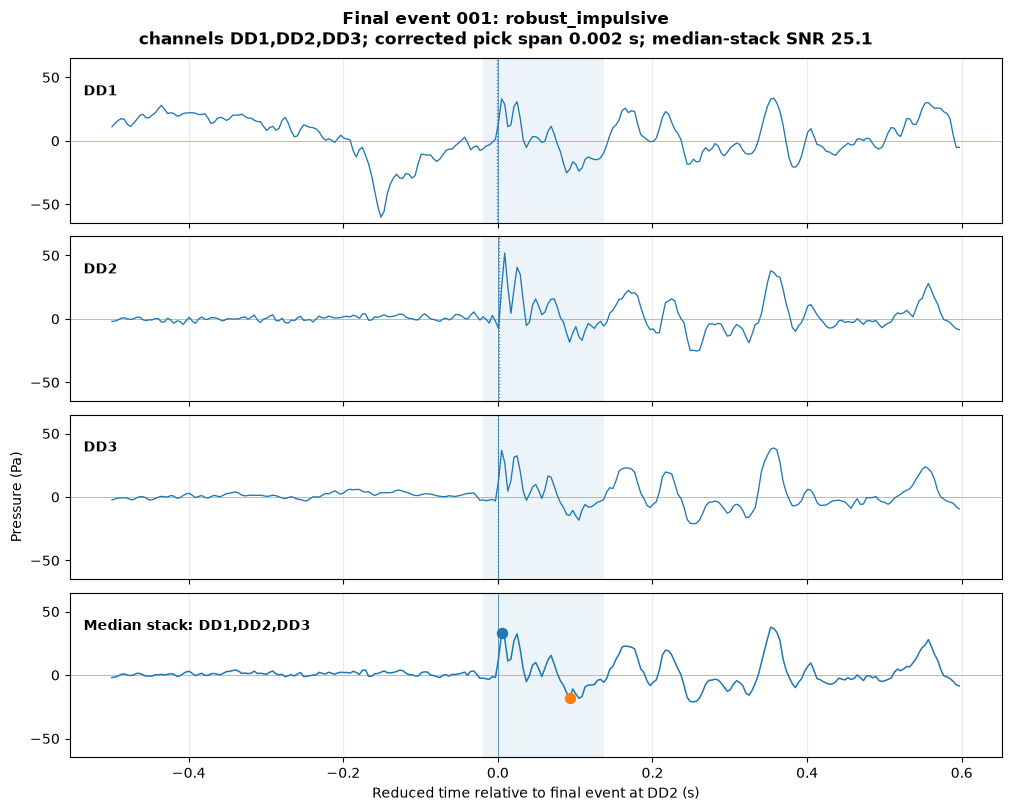

In [12]:
display(
    candidate_events[
        [
            "candidate_event_number",
            "reduced_event_time",
            "channels",
            "corrected_pick_span_s",
            "median_stack_snr",
            "positive_peak_pa",
            "negative_peak_pa",
            "positive_negative_lag_s",
            "event_start_s",
            "event_end_s",
            "quality_class",
            "segment_file",
        ]
    ].head(20)
)

PREVIEW_EVENT_NUMBER = int(
    candidate_events.iloc[0]["candidate_event_number"]
)
preview = build_candidate_event_figure(PREVIEW_EVENT_NUMBER)
plt.show()

## Production outputs

The output paths remain compatible with the downstream planar-array analysis:

```text
data/outputs/070_prepare_event_waveform_products/
    event_streams/candidate_event_001.pkl ...
    derived/final_event_waveform_products.csv
    derived/candidate_airwave_event_catalogue.csv  # legacy alias
    derived/candidate_event_pick_assignments.csv
    derived/candidate_event_stream_index.csv
    derived/unassociated_accepted_infrasound_picks.csv
    derived/candidate_event_processing_metadata.json
```

Saved six-channel segments retain observed receiver UTC; only diagnostic
pressure arrays are shifted to the reference sensor. These approximately
1.1-s caches are not proof of complete pulse or seismic-coda capture. Closely
spaced segments overlap and do not represent independent physical explosions.
The shared whole-event MiniSEED and metadata suffice to regenerate all caches.
Additional audit outputs are `event_segment_sample_coverage.csv` and
`excluded_candidate_pick_assignments.csv`.
